# Retrieval

This notebook is made to verify the RAC retriever's model.
Change the three config variables to switch between indexes and use different hyperparameters.

**Two retrieval behaviours:**
- **Test-time** (`chunk_id=None`): sample is not in the index → return the k closest chunks directly.
- **Train-time** (`chunk_id=int`): sample IS in the index → search k+1 samples, remove the self-match by id, return k closest chunks.

## 1. Imports

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import torch
import faiss
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

# add src/ to path so shared modules (retriever, data_loaders, ...) are importable
sys.path.insert(0, str(Path("..").resolve()))

## 2. Configuration

Change `INDEX_SPLIT` to switch between the three available FAISS indices.  
Change K (maximum number of chunks to retrieve) and THRESHOLD (minimum cosine similarity to retrieve) as you like.  
The retriever is always `sentence-transformers/all-mpnet-base-v2` (SBERT with mean pooling).

In [2]:
INDEX_SPLIT = "example"    # "example" | "knowledge" | "full"
K         = 3
THRESHOLD = 0.95

In [3]:
# Define different paths and the retriever's encoder name then prints it
CORPUS_DIR  = Path("../../corpus")
INDEX_DIR   = CORPUS_DIR / "index"
CHUNKS_DIR  = CORPUS_DIR / "chunks"
index_path  = INDEX_DIR / f"vdb_{INDEX_SPLIT}.faiss"
lookup_path = INDEX_DIR / f"lookup_{INDEX_SPLIT}.json"

SBERT_HF_ID = "sentence-transformers/all-mpnet-base-v2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device      : {device}")
print(f"Retriever   : {SBERT_HF_ID}")
print(f"Index split : {INDEX_SPLIT}")
print(f"Index path  : {index_path}")

Device      : cuda
Retriever   : sentence-transformers/all-mpnet-base-v2
Index split : example
Index path  : ../../corpus/index/vdb_example.faiss


## 3. Load Retriever, Index & Documents

Load the SBERT retriever from HuggingFace and the chosen FAISS index.

In [4]:
# Load SBERT tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(SBERT_HF_ID)
model     = AutoModel.from_pretrained(SBERT_HF_ID).eval().to(device)

# Load the index following the index_path
index = faiss.read_index(str(index_path))
print(f"Index loaded  — {index.ntotal:,} vectors  dim={index.d}")

# Load the lookup table following lookup_path
with open(lookup_path) as f:
    documents = json.load(f)
print(f"Lookup loaded — {len(documents):,} entries")

Index loaded  — 67,864 vectors  dim=768
Lookup loaded — 67,864 entries


In [5]:
# Load encode function and different retriever functions
from retriever import encode, retrieve_top_k, retrieve_top_k_above_threshold

## 5. Retriver at Test-time

Queries without a `chunk_id` (simulating the test set, where tweets are not in the index).

In [6]:
# Here you can write any query you like to test the retriever at test time
test_queries = [
    ("HATE",     "jews are now in full control : canadian man goes to jail for posting on white nationalist websites"),
    ("HATE",     "i dont like neggers"),
    ("NOT HATE", "i dont like tomatoes"),
    ("NOT HATE", "Charges in deadly wreck that killed 5 motorcyclists . Crash takes injured woman s fiance , mom ."),
]

for label, tweet in test_queries:
    print(f"[{label}] {tweet}")

    print(f"retrieve_top_k (k={K})")
    for text, score in retrieve_top_k(tweet, model, tokenizer, index, documents, K, use_mean_pool=True):
        print(f"    {score:.4f}  {text[:90]}")

    # Uncomment to test retrieve_by_threshold (WARNING: can return hundreds of results):
    # print(f"  -- retrieve_by_threshold (threshold={THRESHOLD}) --")
    # hits = retrieve_by_threshold(tweet, THRESHOLD, model, tokenizer, index, documents)
    # for text, score in hits or []:
    #     print(f"    {score:.4f}  {text[:90]}")
    # if not hits:
    #     print("    (no results above threshold)")

    print(f"retrieve_top_k_above_threshold (threshold={THRESHOLD}, k=10)")
    hits = retrieve_top_k_above_threshold(tweet, THRESHOLD, model, tokenizer, index, documents, K, use_mean_pool=True)
    if hits:
        for text, score in hits:
            print(f"    {score:.4f}  {text[:90]}")
    else:
        print("    (no results above threshold)")

[HATE] jews are now in full control : canadian man goes to jail for posting on white nationalist websites
retrieve_top_k (k=3)


Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00,  4.85it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00,  4.82it/s]

    0.9739  [hate] jews are now in full control : canadian man goes to jail for posting on white natio
    0.9313  [hate] : jews are now in full control : canadian man goes to jail for posting on white nat
    0.9045  [not hate] jews are now in full control : canadian man goes to jail for posting on white n
    0.6276  [hate] internet censorship ramps up as second white nationalist website has dns seized via
retrieve_top_k_above_threshold (threshold=0.95, k=10)


...

Encoding: 100%|██████████| 1/1 [00:00<00:00, 124.56it/s]

    0.7180  [not hate] Read more : Charges in deadly wreck that killed 5 motorcyclists - LancasterOnli
    0.3678  [not hate] Fatal shooting victim Police find murder victim Clinton woman 's death ruled a 
    0.3645  [hate] Women drivers no survivors
    0.3451  [not hate] Anthony DeShawn Washington , 18 , of Avondale , and Jonathan Anthony Gutierrez 
retrieve_top_k_above_threshold (threshold=0.95, k=10)


Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 125.77it/s]

    (no results above threshold)


## 6. Retriver at Train-time

Here, the retriever mask the query as it is present in the index.

For 3 randomly sampled training tweets, we verify that:
1. The tweet's own text does **not** appear in the retrieved neighbors when `chunk_id` is passed.
2. It **does** appear (as the top result) when `chunk_id=None` is passed (confirming it was in the index).

In [7]:
# If we choose the knowledge index, self-exclusion has no sense so we don't continue
if INDEX_SPLIT == "knowledge":
    print(f"Skipping self-exclusion check because INDEX_SPLIT='{INDEX_SPLIT}' (tweets not in this index).")
else:
    # Load the chunks
    df = pd.read_csv(CHUNKS_DIR / "chunks_example.csv")

    # Define a function to remove the labels from the chunks since the query should not have it
    def strip_prefix(text):
        return text.replace("[hate] ", "", 1).replace("[not hate] ", "", 1)

    # Take randomly 3 examples from the chunks
    sample = df.sample(3, random_state=42)

    for _, row in sample.iterrows():
        # Supress the label prefix to create the query and remember its id for masking
        raw = strip_prefix(row.text)
        cid = int(row.chunk_id)

        # Test the retriver with and without exclusion of the query's chunk id
        without_exclusion = retrieve_top_k(raw, model, tokenizer, index, documents, chunk_id=None, k=K, use_mean_pool=True)
        with_exclusion    = retrieve_top_k(raw, model, tokenizer, index, documents, chunk_id=cid,  k=K, use_mean_pool=True)

        # Check wether the query has been retrieved (should be true for without and false for with) by looking at the retrieved samples ids
        self_in_without = any(text == row.text for text, _ in without_exclusion)
        self_in_with    = any(text == row.text for text, _ in with_exclusion)

        # Print the retrieved chunks and assert what we said in the previous comment
        print(f"chunk_id={cid}  |  {raw[:80]}")
        print(f"  Self present WITHOUT exclusion : {self_in_without}  (expected True)")
        print(f"  Self present WITH    exclusion : {self_in_with}   (expected False)")
        assert self_in_without, f"chunk_id={cid} not found in index — check index"
        assert not self_in_with, f"Self-exclusion failed for chunk_id={cid}"

    print("\nAll self-exclusion checks passed.")

Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 123.17it/s]

Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 113.23it/s]

chunk_id=2909  |  pl . note trump is not racist  this is false propaganda of opponents
  Self present WITHOUT exclusion : True  (expected True)
  Self present WITH    exclusion : False   (expected False)


...

Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 121.03it/s]

Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 124.25it/s]

chunk_id=57254  |  "in our heavily populated cities , with their fancy stores and restaurants , we 
  Self present WITHOUT exclusion : True  (expected True)
  Self present WITH    exclusion : False   (expected False)

All self-exclusion checks passed.


## 7. Vector-Space Analysis

Geometric analysis of the embedding space on a random sample of `N_SAMPLE` vectors. Covers norm statistics, effective rank (how many dimensions carry variance), isotropy (how spread the vectors are), and whether hate vs not-hate embeddings form geometrically separated clusters.

Encoding 2000 random samples...


Encoding:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding:   6%|▋         | 2/32 [00:00<00:02, 13.80it/s]

Encoding:  12%|█▎        | 4/32 [00:00<00:01, 14.32it/s]

Encoding:  19%|█▉        | 6/32 [00:00<00:01, 15.75it/s]

...

Encoding:  91%|█████████ | 29/32 [00:01<00:00, 19.32it/s]

Encoding:  97%|█████████▋| 31/32 [00:01<00:00, 19.32it/s]

Encoding: 100%|██████████| 32/32 [00:01<00:00, 18.42it/s]


── Norm statistics (pre-normalisation) ──
  mean : 2.6203
  std  : 0.1305
  min  : 2.2037   max : 3.1425



── Effective rank ──
  Effective rank : 465.1  /  768  dimensions

── Pairwise cosine similarity ──
  mean : 0.3558   std : 0.1088
  → Good spread across the sphere


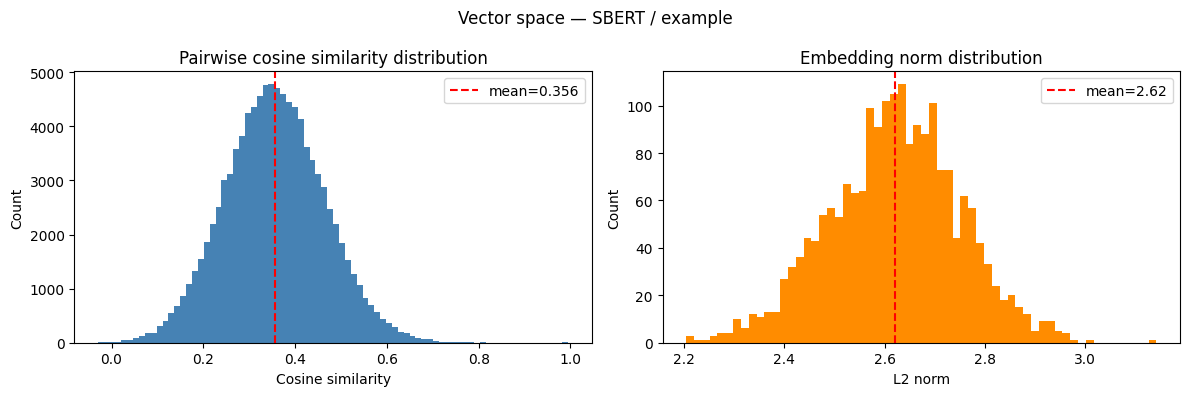


── Intra- vs inter-class cosine similarity ──
  hate    ↔ hate    (intra) : 0.3646
  nothate ↔ nothate (intra) : 0.3882
  hate    ↔ nothate (inter) : 0.3389
  Separation gap (intra_mean − inter) : 0.0375  ← good separation


In [8]:
N_SAMPLE = 2000  # number of random vectors to draw from the index

# re-encode a random sample to get raw (pre-normalisation) vectors
rng = np.random.default_rng(0)
all_ids = list(documents.keys())
sample_ids = rng.choice(all_ids, size=min(N_SAMPLE, len(all_ids)), replace=False)
sample_texts = [documents[sid] for sid in sample_ids]

print(f"Encoding {len(sample_texts)} random samples...")
raw_vecs = encode(sample_texts, model, tokenizer, use_mean_pool=True)   # shape (N, D), un-normalised

# 1. norm statistics
norms = np.linalg.norm(raw_vecs, axis=1)
print(f"\n── Norm statistics (pre-normalisation) ──")
print(f"  mean : {norms.mean():.4f}")
print(f"  std  : {norms.std():.4f}")
print(f"  min  : {norms.min():.4f}   max : {norms.max():.4f}")

# 2. effective rank: exp(entropy of normalised singular values), ranges from 1 to D
centered = raw_vecs - raw_vecs.mean(axis=0)
_, sv, _ = np.linalg.svd(centered, full_matrices=False)
sv_norm = sv / sv.sum()
entropy = -np.sum(sv_norm * np.log(sv_norm + 1e-12))
eff_rank = np.exp(entropy)
print(f"\n── Effective rank ──")
print(f"  Effective rank : {eff_rank:.1f}  /  {raw_vecs.shape[1]}  dimensions")

# 3. isotropy: mean pairwise cosine similarity (lower = better spread)
normed = raw_vecs / (norms[:, None] + 1e-12)
# pairwise cosines via matrix multiply, diagonal set to nan to exclude self-pairs
cos_matrix = normed @ normed.T
np.fill_diagonal(cos_matrix, np.nan)
pairwise = cos_matrix[~np.isnan(cos_matrix)]
mean_cos = np.nanmean(pairwise)
std_cos  = np.nanstd(pairwise)
print(f"\n── Pairwise cosine similarity ──")
print(f"  mean : {mean_cos:.4f}   std : {std_cos:.4f}")
print(f"  → {'High anisotropy — vectors cluster tightly' if mean_cos > 0.95 else 'Good spread across the sphere' if mean_cos < 0.85 else 'Moderate spread'}")

# 4. plot cosine similarity and norm distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Vector space — SBERT / {INDEX_SPLIT}")

# subsample pairs to keep the histogram manageable
pair_sample = rng.choice(pairwise, size=min(100_000, len(pairwise)), replace=False)
axes[0].hist(pair_sample, bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(mean_cos, color="red", linestyle="--", label=f"mean={mean_cos:.3f}")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Pairwise cosine similarity distribution")
axes[0].legend()

axes[1].hist(norms, bins=60, color="darkorange", edgecolor="none")
axes[1].axvline(norms.mean(), color="red", linestyle="--", label=f"mean={norms.mean():.2f}")
axes[1].set_xlabel("L2 norm")
axes[1].set_ylabel("Count")
axes[1].set_title("Embedding norm distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. intra vs inter class similarity
hate_mask    = np.array([documents[sid].startswith("[hate]")     for sid in sample_ids])
nothate_mask = np.array([documents[sid].startswith("[not hate]") for sid in sample_ids])

def mean_block_similarity(mask_a, mask_b, cos_mat):
    block = cos_mat[np.ix_(mask_a, mask_b)]
    if mask_a is mask_b:
        np.fill_diagonal(block, np.nan)
    return np.nanmean(block)

if hate_mask.sum() > 1 and nothate_mask.sum() > 1:
    intra_hate    = mean_block_similarity(hate_mask, hate_mask, cos_matrix)
    intra_nothate = mean_block_similarity(nothate_mask, nothate_mask, cos_matrix)
    inter         = mean_block_similarity(hate_mask, nothate_mask, cos_matrix)
    print(f"\n── Intra- vs inter-class cosine similarity ──")
    print(f"  hate    ↔ hate    (intra) : {intra_hate:.4f}")
    print(f"  nothate ↔ nothate (intra) : {intra_nothate:.4f}")
    print(f"  hate    ↔ nothate (inter) : {inter:.4f}")
    sep_ratio = ((intra_hate + intra_nothate) / 2 - inter)
    print(f"  Separation gap (intra_mean − inter) : {sep_ratio:.4f}  {'← good separation' if sep_ratio > 0.01 else '← classes overlap'}")
else:
    print("\n(Not enough labelled samples to compute intra/inter-class similarity)")